# Load libraries

In [6]:
import sys
sys.path.insert(0, '/Users/svijaysh/NPP+DCfork/H2Integrate')
import os
from h2integrate import EXAMPLE_DIR
os.chdir(EXAMPLE_DIR/"32_nuclear_DC_case_2")
import numpy as np
import pandas as pd
from h2integrate.core.h2integrate_model import H2IntegrateModel



# Setup H2I model with nuclear + DC yaml file

In [7]:
h2i = H2IntegrateModel("nuclear_datacenter_config_case_2.yaml")
h2i.setup()

In [8]:
system_capacity = h2i.prob.get_val("plant.nuclear.QuinnNuclearPerformanceModel.system_capacity", units="kW")
print(f"System capacity: {system_capacity[0]:.2f} kW")

System capacity: 1000000.00 kW


## The current setup is:

NPP is connected to he grid (selling all its power to the grid at 0.05/kwh)
The DC buys power from the grid. 

In [9]:
results = []
ts_data  = {}  # time-series keyed by nuclear capacity in MW

for capacity_mw in [500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500]:
    capacity_kw = capacity_mw * 1000

    h2i.prob.set_val("nuclear.system_capacity", capacity_kw, units="kW")
    h2i.prob.set_val("nuclear.electricity_demand", capacity_kw, units="kW")

    h2i.run()

    results.append({
        "nuclear_mw":              capacity_mw,
        "lcoe":                    h2i.prob.get_val("finance_subgroup_nuclear.LCOE", units="USD/(kW*h)")[0],
        "capacity_factor":         h2i.prob.get_val("nuclear.capacity_factor")[0],
        "nuclear_elec_demand": h2i.prob.get_val("nuclear.electricity_demand").mean(),
        "electricity_demand":      h2i.prob.get_val("electrical_load_demand.electricity_demand").mean(),
        "electricity_unmet_demand":h2i.prob.get_val("electrical_load_demand.electricity_unmet_demand").mean(),
        "grid_demand_mean_mw":     h2i.prob.get_val("grid.electricity_demand", units="kW").mean() / 1e3,
        # Capital costs
        "nuclear_capex_B$":        h2i.prob.get_val("nuclear.CapEx", units="USD")[0] / 1e9,
        "grid_capex_M$":           h2i.prob.get_val("grid.CapEx",    units="USD")[0] / 1e6,
        # Annual operating costs
        "nuclear_opex_M$":         h2i.prob.get_val("nuclear.OpEx",    units="USD/year")[0] / 1e6,
        "nuclear_varopex_M$":      h2i.prob.get_val("nuclear.VarOpEx", units="USD/year")[0] / 1e6,
        "grid_opex_M$":            h2i.prob.get_val("grid.OpEx",       units="USD/year")[0] / 1e6,
    })

    # Full hourly time-series
    ts_data[capacity_mw] = {
        "nuclear_out_mw":  h2i.prob.get_val("nuclear.electricity_out",                         units="kW") / 1e3,
        "unmet_mw":        h2i.prob.get_val("electrical_load_demand.electricity_unmet_demand", units="kW") / 1e3,
        "grid_demand_mw":  h2i.prob.get_val("grid.electricity_demand",                         units="kW") / 1e3,
        "dc_demand_mw":    h2i.prob.get_val("electrical_load_demand.electricity_demand",        units="kW") / 1e3,
    }

df = pd.DataFrame(results)
df["total_opex_M$"] = df["nuclear_opex_M$"] + df["nuclear_varopex_M$"] + df["grid_opex_M$"]
df

/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_

,nuclear_mw,lcoe,capacity_factor,nuclear_elec_demand,electricity_demand,electricity_unmet_demand,grid_demand_mean_mw,nuclear_capex_B$,grid_capex_M$,nuclear_opex_M$,nuclear_varopex_M$,grid_opex_M$,total_opex_M$
0,500,0.118862,1.0,500000.0,2000000.0,1500000.0,1500.0,3.606101,100.0,75.0,65.70,5.0,145.70
1,750,0.112720,1.0,750000.0,2000000.0,1250000.0,1250.0,5.089972,100.0,112.5,98.55,5.0,216.05
2,1000,0.108782,1.0,1000000.0,2000000.0,1000000.0,1000.0,6.500000,100.0,150.0,131.40,5.0,286.40
3,1250,0.105927,1.0,1250000.0,2000000.0,750000.0,750.0,7.857545,100.0,187.5,164.25,5.0,356.75
4,1500,0.103707,1.0,1500000.0,2000000.0,500000.0,500.0,9.174680,100.0,225.0,197.10,5.0,427.10
5,1750,0.101902,1.0,1750000.0,2000000.0,250000.0,250.0,10.459133,100.0,262.5,229.95,5.0,497.45
6,2000,0.100388,1.0,2000000.0,2000000.0,0.0,0.0,11.716256,100.0,300.0,262.80,5.0,567.80
7,2250,0.099088,1.0,2250000.0,2000000.0,0.0,0.0,12.949962,100.0,337.5,295.65,5.0,638.15
8,2500,0.097953,1.0,2500000.0,2000000.0,0.0,0.0,14.163232,100.0,375.0,328.50,5.0,708.50


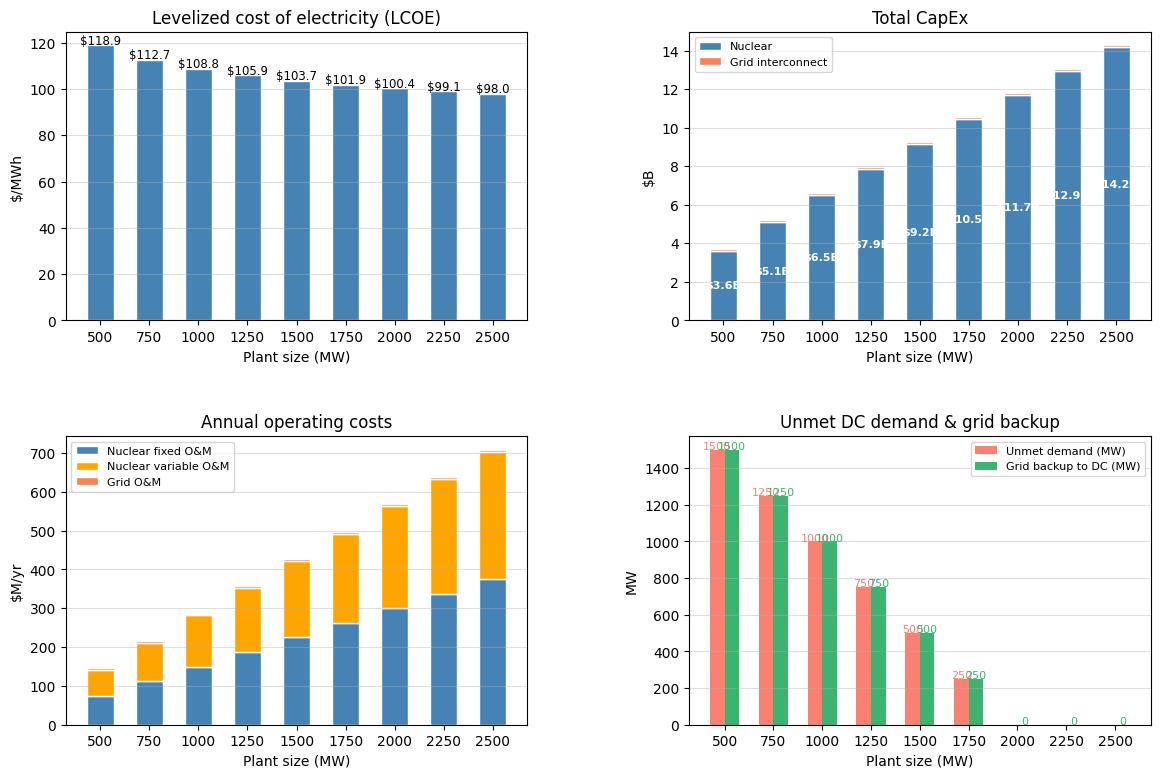

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plt.subplots_adjust(hspace=0.4, wspace=0.35)

sizes  = df["nuclear_mw"].values.astype(float)
labels = [f"{int(s)}" for s in sizes]
x = np.arange(len(sizes))
W = 0.55

# -- LCOE --
ax = axes[0, 0]
lcoe_mwh = df["lcoe"].values * 1000
ax.bar(x, lcoe_mwh, W, color="steelblue", edgecolor="white")
for xi, v in zip(x, lcoe_mwh):
    ax.text(xi, v + 0.5, f"${v:.1f}", ha="center", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Plant size (MW)")
ax.set_ylabel("$/MWh")
ax.set_title("Levelized cost of electricity (LCOE)")
ax.grid(axis="y", alpha=0.4)

# -- CapEx breakdown --
ax = axes[0, 1]
nuc  = df["nuclear_capex_B$"].values
grid = df["grid_capex_M$"].values / 1e3
ax.bar(x, nuc,  W, color="steelblue",  label="Nuclear",          edgecolor="white")
ax.bar(x, grid, W, bottom=nuc, color="coral", label="Grid interconnect", edgecolor="white")
for xi, n, g in zip(x, nuc, grid):
    ax.text(xi, n/2, f"${n:.1f}B", ha="center", va="center",
            fontsize=8, fontweight="bold", color="white")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Plant size (MW)")
ax.set_ylabel("$B")
ax.set_title("Total CapEx")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.4)

# -- Annual OpEx breakdown --
ax = axes[1, 0]
op  = df["nuclear_opex_M$"].values
vop = df["nuclear_varopex_M$"].values
gop = df["grid_opex_M$"].values
ax.bar(x, op,  W, color="steelblue",      label="Nuclear fixed O&M",    edgecolor="white")
ax.bar(x, vop, W, bottom=op,       color="orange",    label="Nuclear variable O&M", edgecolor="white")
ax.bar(x, gop, W, bottom=op+vop,   color="coral",     label="Grid O&M",             edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Plant size (MW)")
ax.set_ylabel("$M/yr")
ax.set_title("Annual operating costs")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.4)

# -- Unmet demand & grid backup --
ax = axes[1, 1]
unmet = df["electricity_unmet_demand"].values / 1e3   # kW → MW
grid_bk = df["grid_demand_mean_mw"].values

ax.bar(x - 0.15, unmet,   0.3, color="salmon",      label="Unmet demand (MW)")
ax.bar(x + 0.15, grid_bk, 0.3, color="mediumseagreen", label="Grid backup to DC (MW)")
for xi, u, g in zip(x, unmet, grid_bk):
    if u > 0:
        ax.text(xi - 0.15, u + 2, f"{u:.0f}", ha="center", fontsize=8, color="salmon")
    ax.text(xi + 0.15, g + 2, f"{g:.0f}", ha="center", fontsize=8, color="mediumseagreen")

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Plant size (MW)")
ax.set_ylabel("MW")
ax.set_title("Unmet DC demand & grid backup")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.4)

plt.show()
